# Visualizacao dos Resultados de Classificacao

Este notebook carrega os CSVs ja gerados pela pasta `classificacao/outputs` e organiza tabelas e graficos para comparar os modelos. Ele nao reroda os treinos nem os testes; usa apenas os arquivos salvos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib nao esta instalado; as tabelas serao exibidas e os graficos serao pulados.")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

if plt is not None:
    plt.style.use("seaborn-v0_8-whitegrid")

## 1. Carregamento dos CSVs

In [2]:
candidate_dirs = [
    Path("outputs"),
    Path("classificacao/outputs"),
    Path("EstresseHidricoFinal/classificacao/outputs"),
]

BASE_DIR = next((path for path in candidate_dirs if path.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("Nao encontrei a pasta outputs da classificacao.")

print(f"Pasta de resultados: {BASE_DIR.resolve()}")

def ler_csvs(nome_arquivo):
    arquivos = sorted(BASE_DIR.rglob(nome_arquivo))
    tabelas = []
    for arquivo in arquivos:
        df = pd.read_csv(arquivo, sep=";")
        df["arquivo_origem"] = str(arquivo.relative_to(BASE_DIR))
        tabelas.append(df)
    if not tabelas:
        return pd.DataFrame()
    return pd.concat(tabelas, ignore_index=True)

metricas_resumo = ler_csvs("metricas_resumo.csv")
metricas_folds = ler_csvs("metricas_folds.csv")
predicoes = ler_csvs("predicoes.csv")
matrizes = ler_csvs("matriz_confusao_folds.csv")
curvas_roc = ler_csvs("curva_roc_folds.csv")

importancia_rf = ler_csvs("importancia_bandas.csv")
importancia_svm = ler_csvs("importancia_permutacao.csv")
coeficientes_pls = ler_csvs("coeficientes_pls.csv")
pesos_pls = ler_csvs("pesos_pls.csv")

print(f"metricas_resumo: {metricas_resumo.shape}")
print(f"metricas_folds: {metricas_folds.shape}")
print(f"predicoes: {predicoes.shape}")
print(f"matrizes: {matrizes.shape}")
print(f"curvas_roc: {curvas_roc.shape}")

## 2. Tabelas de metricas

In [3]:
metric_cols_media = [
    "accuracy_media", "precision_media", "recall_media",
    "f1_score_media", "kappa_media", "auc_roc_media",
]
metric_cols_desvio = [col.replace("_media", "_desvio") for col in metric_cols_media]

metricas_resumo_ordenado = metricas_resumo.sort_values(
    ["modo", "genotipo", "accuracy_media"], ascending=[True, True, False]
).reset_index(drop=True)

metricas_resumo_ordenado[
    ["modelo", "modo", "genotipo", *metric_cols_media, *metric_cols_desvio]
]

,modelo,modo,genotipo,accuracy_media,precision_media,recall_media,f1_score_media,kappa_media,auc_roc_media,accuracy_desvio,precision_desvio,recall_desvio,f1_score_desvio,kappa_desvio,auc_roc_desvio
0,random_forest,agrupado,todos,0.956337,0.953580,0.959375,0.956341,0.912673,0.988848,0.008916,0.011208,0.018561,0.009143,0.017835,0.002796
1,svm,agrupado,todos,0.882535,0.859913,0.913542,0.885791,0.765096,0.951131,0.013683,0.013354,0.022881,0.013979,0.027370,0.012643
2,pls_da,agrupado,todos,0.844067,0.794941,0.927083,0.855729,0.688235,0.903298,0.018093,0.018649,0.027313,0.016983,0.036205,0.024591
3,random_forest,por_genotipo,BR16,0.954688,0.956256,0.953125,0.954443,0.909375,0.989624,0.019453,0.016954,0.033146,0.020090,0.038906,0.005482
4,svm,por_genotipo,BR16,0.876563,0.867636,0.890625,0.878070,0.753125,0.949170,0.027841,0.036265,0.048159,0.028807,0.055683,0.016246
5,pls_da,por_genotipo,BR16,0.759375,0.780092,0.731250,0.749707,0.518750,0.843994,0.042576,0.051958,0.107347,0.058147,0.085153,0.038268
6,random_forest,por_genotipo,CD202,0.972032,0.969208,0.975000,0.971868,0.944068,0.996415,0.007052,0.010038,0.023696,0.007508,0.014108,0.002349
7,svm,por_genotipo,CD202,0.919259,0.902586,0.940625,0.920525,0.838560,0.963193,0.011720,0.030066,0.030055,0.010670,0.023394,0.010308
8,pls_da,por_genotipo,CD202,0.847759,0.813722,0.900000,0.854630,0.695689,0.946584,0.032738,0.031130,0.032401,0.030710,0.065520,0.012514
9,random_forest,por_genotipo,EMB48,0.971875,0.981052,0.962500,0.971627,0.943750,0.996899,0.017116,0.020621,0.017815,0.017215,0.034233,0.002230


In [4]:
ranking_accuracy = metricas_resumo.sort_values("accuracy_media", ascending=False)[
    ["modelo", "modo", "genotipo", "accuracy_media", "accuracy_desvio", "auc_roc_media", "f1_score_media"]
].reset_index(drop=True)

ranking_auc = metricas_resumo.sort_values("auc_roc_media", ascending=False)[
    ["modelo", "modo", "genotipo", "auc_roc_media", "auc_roc_desvio", "accuracy_media", "f1_score_media"]
].reset_index(drop=True)

display(ranking_accuracy)
display(ranking_auc)

,modelo,modo,genotipo,accuracy_media,accuracy_desvio,auc_roc_media,f1_score_media
0,random_forest,por_genotipo,CD202,0.972032,0.007052,0.996415,0.971868
1,random_forest,por_genotipo,EMB48,0.971875,0.017116,0.996899,0.971627
2,random_forest,agrupado,todos,0.956337,0.008916,0.988848,0.956341
3,random_forest,por_genotipo,BR16,0.954688,0.019453,0.989624,0.954443
4,svm,por_genotipo,CD202,0.919259,0.011720,0.963193,0.920525
5,svm,por_genotipo,EMB48,0.903125,0.052291,0.962402,0.903124
6,svm,agrupado,todos,0.882535,0.013683,0.951131,0.885791
7,svm,por_genotipo,BR16,0.876563,0.027841,0.949170,0.878070
8,pls_da,por_genotipo,EMB48,0.868750,0.053389,0.924414,0.860837
9,pls_da,por_genotipo,CD202,0.847759,0.032738,0.946584,0.854630


,modelo,modo,genotipo,auc_roc_media,auc_roc_desvio,accuracy_media,f1_score_media
0,random_forest,por_genotipo,EMB48,0.996899,0.002230,0.971875,0.971627
1,random_forest,por_genotipo,CD202,0.996415,0.002349,0.972032,0.971868
2,random_forest,por_genotipo,BR16,0.989624,0.005482,0.954688,0.954443
3,random_forest,agrupado,todos,0.988848,0.002796,0.956337,0.956341
4,svm,por_genotipo,CD202,0.963193,0.010308,0.919259,0.920525
5,svm,por_genotipo,EMB48,0.962402,0.027829,0.903125,0.903124
6,svm,agrupado,todos,0.951131,0.012643,0.882535,0.885791
7,svm,por_genotipo,BR16,0.949170,0.016246,0.876563,0.878070
8,pls_da,por_genotipo,CD202,0.946584,0.012514,0.847759,0.854630
9,pls_da,por_genotipo,EMB48,0.924414,0.035472,0.868750,0.860837


## 3. Graficos comparativos das metricas medias

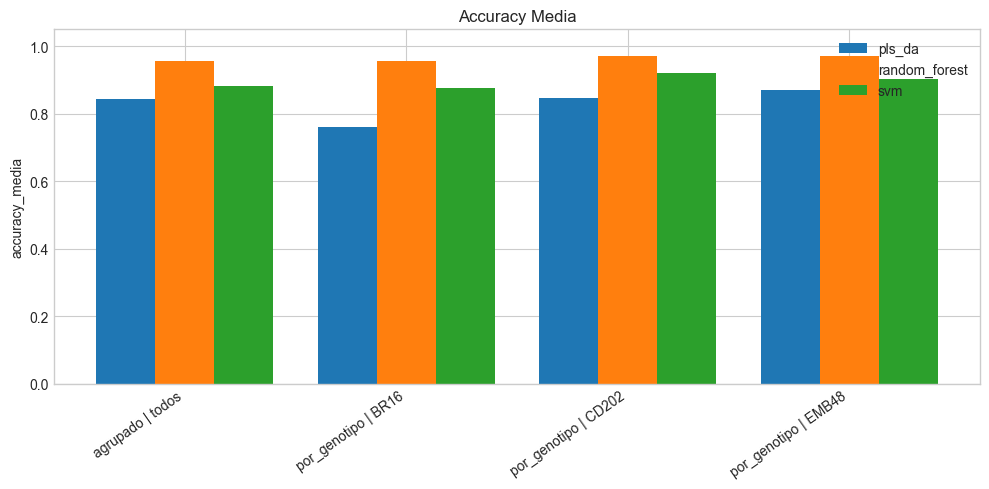

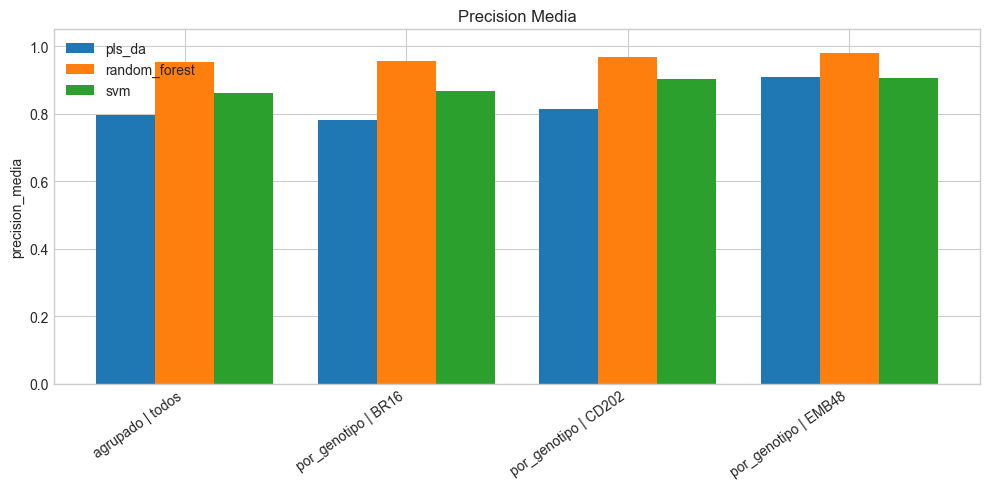

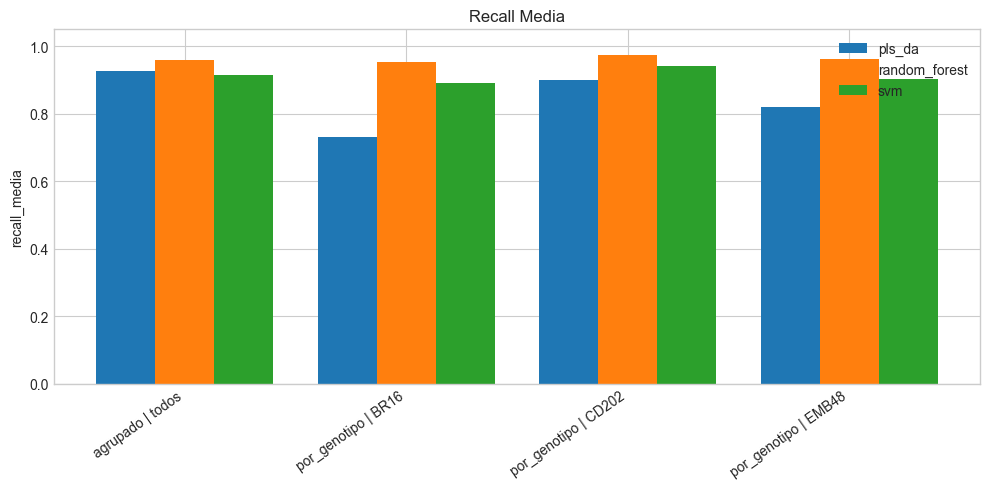

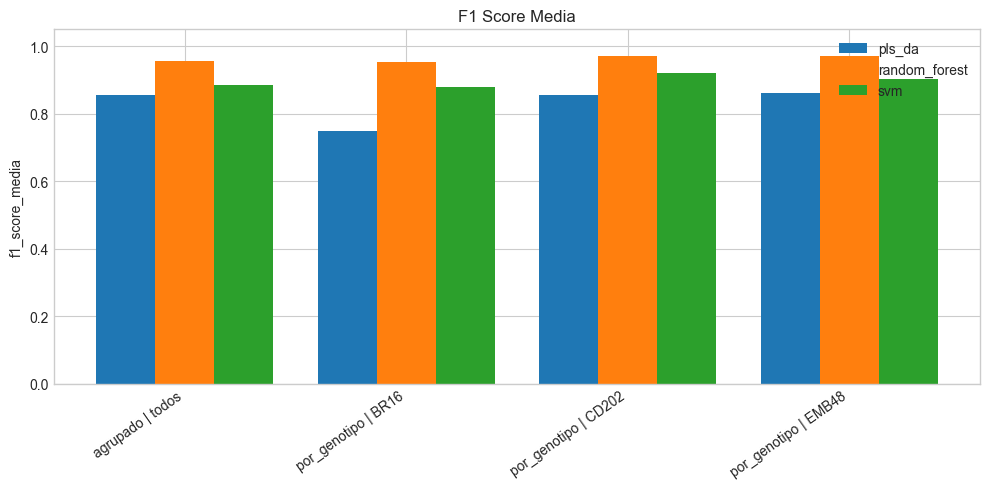

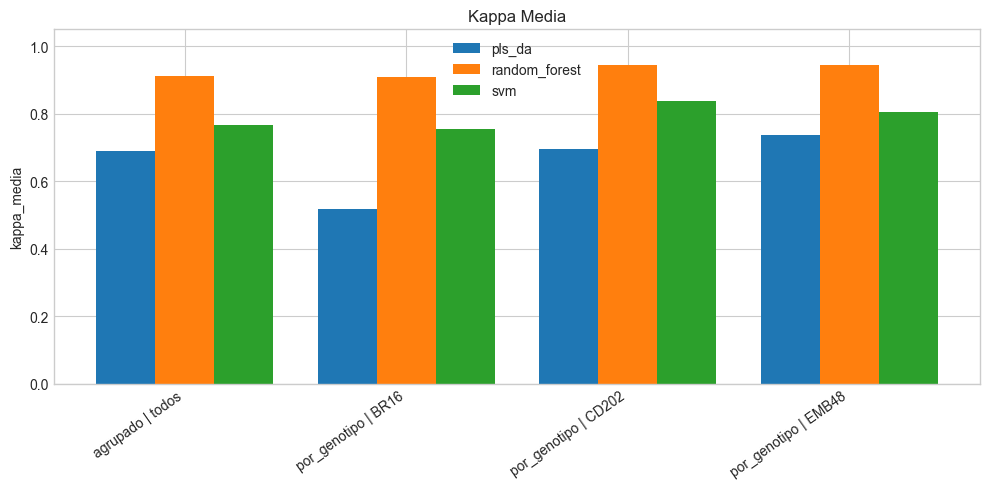

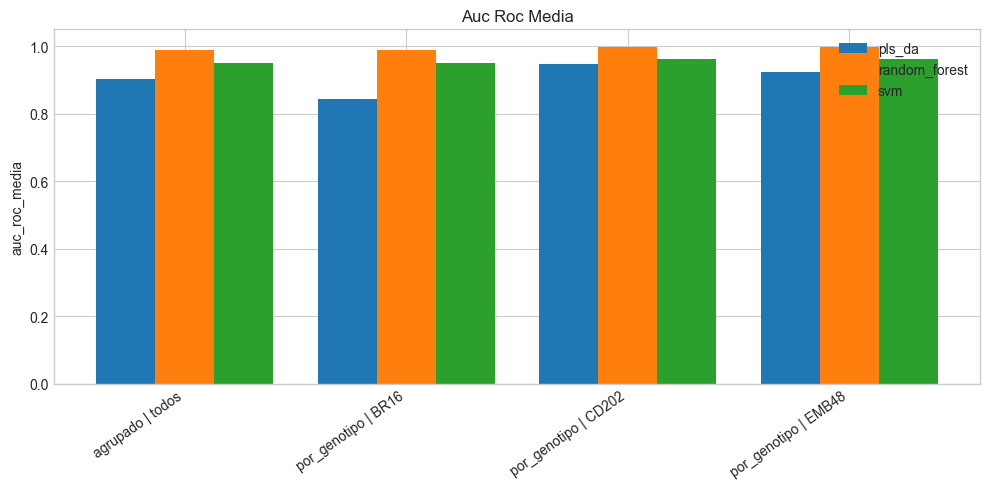

In [5]:
def plot_metricas_por_cenario(df, metrica="accuracy_media"):
    if plt is None:
        print("Grafico pulado: instale matplotlib para visualizar.")
        return
    if df.empty:
        print("Sem dados para plotar.")
        return

    dados = df.copy()
    dados["cenario"] = dados["modo"] + " | " + dados["genotipo"].astype(str)
    cenarios = dados["cenario"].drop_duplicates().tolist()
    modelos = dados["modelo"].drop_duplicates().tolist()

    x = np.arange(len(cenarios))
    width = 0.8 / max(len(modelos), 1)

    fig, ax = plt.subplots(figsize=(max(10, len(cenarios) * 1.6), 5))
    for i, modelo in enumerate(modelos):
        sub = dados[dados["modelo"] == modelo].set_index("cenario").reindex(cenarios)
        ax.bar(x + (i - (len(modelos) - 1) / 2) * width, sub[metrica], width, label=modelo)

    ax.set_title(metrica.replace("_", " ").title())
    ax.set_ylabel(metrica)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(cenarios, rotation=35, ha="right")
    fig.legend(loc="center left", bbox_to_anchor=(0.81, 0.5), frameon=False, title="Modelo")
    plt.tight_layout(rect=(0, 0, 0.80, 1))
    plt.show()

for metrica in ["accuracy_media", "precision_media", "recall_media", "f1_score_media", "kappa_media", "auc_roc_media"]:
    plot_metricas_por_cenario(metricas_resumo, metrica)

## 4. Variabilidade entre folds

In [6]:
metricas_folds.sort_values(["modo", "genotipo", "modelo", "fold"]).reset_index(drop=True)

,modelo,modo,genotipo,fold,accuracy,precision,recall,f1_score,kappa,auc_roc,arquivo_origem
0,pls_da,agrupado,todos,1,0.870130,0.819820,0.947917,0.879227,0.740363,0.926652,agrupado\pls_da\metricas_folds.csv
1,pls_da,agrupado,todos,2,0.838961,0.775424,0.953125,0.855140,0.678111,0.895644,agrupado\pls_da\metricas_folds.csv
2,pls_da,agrupado,todos,3,0.828571,0.794393,0.885417,0.837438,0.657242,0.869468,agrupado\pls_da\metricas_folds.csv
3,pls_da,agrupado,todos,4,0.854545,0.806306,0.932292,0.864734,0.709207,0.928271,agrupado\pls_da\metricas_folds.csv
4,pls_da,agrupado,todos,5,0.828125,0.778761,0.916667,0.842105,0.656250,0.896457,agrupado\pls_da\metricas_folds.csv
5,random_forest,agrupado,todos,1,0.961039,0.963351,0.958333,0.960836,0.922076,0.988005,agrupado\random_forest\metricas_folds.csv
6,random_forest,agrupado,todos,2,0.955844,0.939698,0.973958,0.956522,0.911696,0.989152,agrupado\random_forest\metricas_folds.csv
7,random_forest,agrupado,todos,3,0.948052,0.962366,0.932292,0.947090,0.896095,0.987438,agrupado\random_forest\metricas_folds.csv
8,random_forest,agrupado,todos,4,0.968831,0.959184,0.979167,0.969072,0.937665,0.993469,agrupado\random_forest\metricas_folds.csv
9,random_forest,agrupado,todos,5,0.947917,0.943299,0.953125,0.948187,0.895833,0.986179,agrupado\random_forest\metricas_folds.csv


C:\Users\Vitor\AppData\Local\Temp\ipykernel_4276\3739215296.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos.tolist(), labels=grupos.index, showmeans=True)


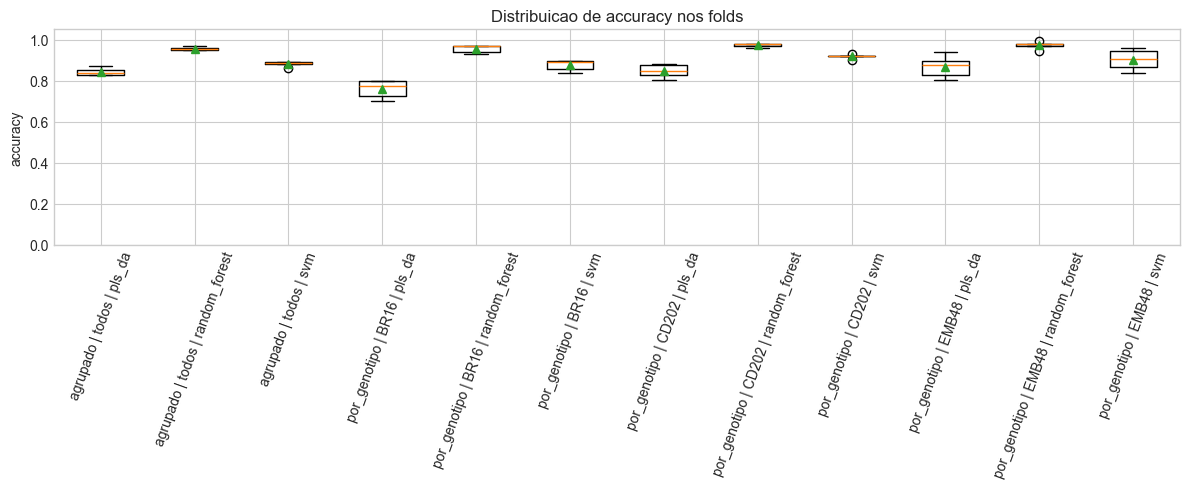

C:\Users\Vitor\AppData\Local\Temp\ipykernel_4276\3739215296.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos.tolist(), labels=grupos.index, showmeans=True)


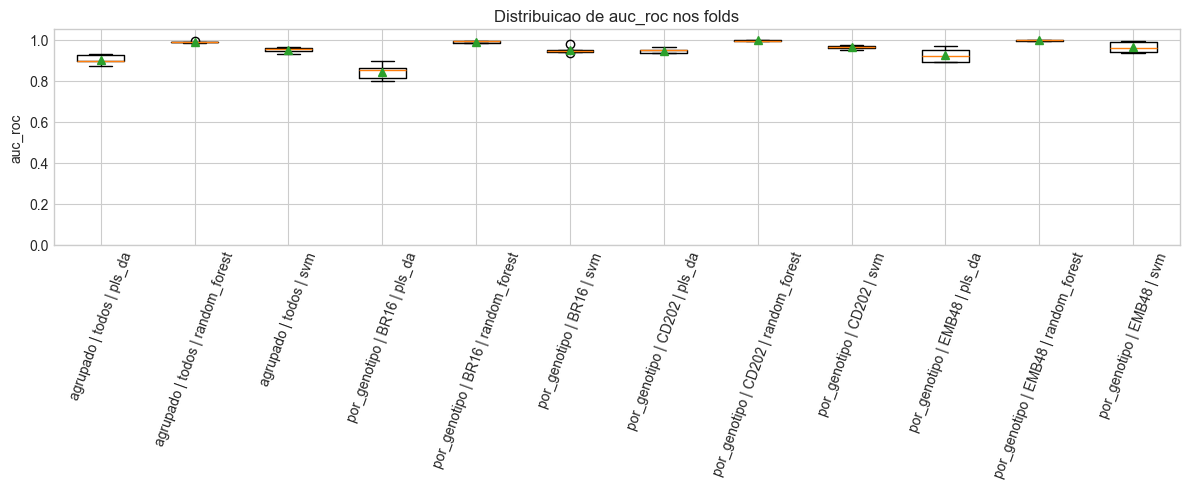

In [7]:
def boxplot_folds(df, metrica="accuracy"):
    if plt is None:
        print("Grafico pulado: instale matplotlib para visualizar.")
        return
    if df.empty:
        print("Sem dados para plotar.")
        return

    dados = df.copy()
    dados["cenario_modelo"] = dados["modo"] + " | " + dados["genotipo"].astype(str) + " | " + dados["modelo"]
    grupos = dados.groupby("cenario_modelo", sort=False)[metrica].apply(list)

    fig, ax = plt.subplots(figsize=(max(12, len(grupos) * 0.8), 5))
    ax.boxplot(grupos.tolist(), labels=grupos.index, showmeans=True)
    ax.set_title(f"Distribuicao de {metrica} nos folds")
    ax.set_ylabel(metrica)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=70)
    plt.tight_layout()
    plt.show()

boxplot_folds(metricas_folds, "accuracy")
boxplot_folds(metricas_folds, "auc_roc")

## 5. Matrizes de confusao

In [8]:
matriz_total = (
    matrizes.groupby(["modelo", "modo", "genotipo", "real", "predito"], as_index=False)["n"].sum()
    .sort_values(["modo", "genotipo", "modelo", "real", "predito"])
)
matriz_total

,modelo,modo,genotipo,real,predito,n
0,pls_da,agrupado,todos,IRRIG,IRRIG,734
1,pls_da,agrupado,todos,IRRIG,NIRRIG,230
2,pls_da,agrupado,todos,NIRRIG,IRRIG,70
3,pls_da,agrupado,todos,NIRRIG,NIRRIG,890
16,random_forest,agrupado,todos,IRRIG,IRRIG,919
17,random_forest,agrupado,todos,IRRIG,NIRRIG,45
18,random_forest,agrupado,todos,NIRRIG,IRRIG,39
19,random_forest,agrupado,todos,NIRRIG,NIRRIG,921
32,svm,agrupado,todos,IRRIG,IRRIG,821
33,svm,agrupado,todos,IRRIG,NIRRIG,143


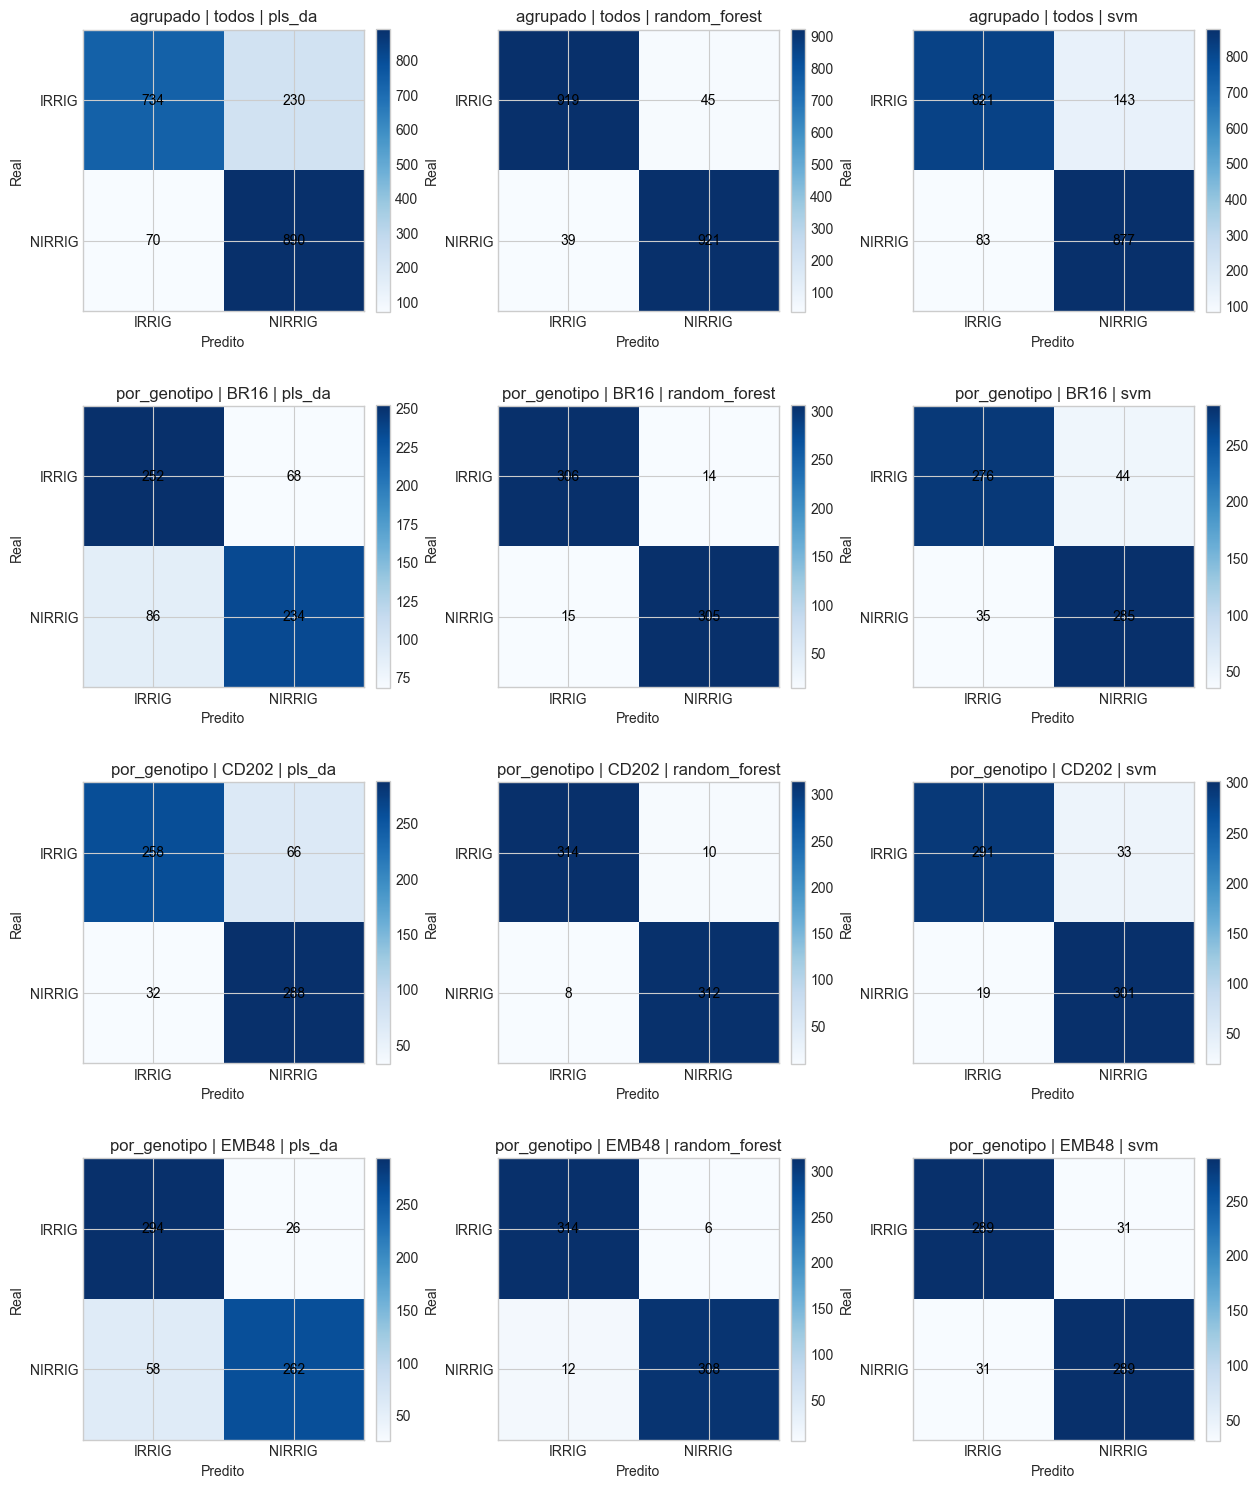

In [9]:
def plot_matrizes_confusao(df):
    if plt is None:
        print("Grafico pulado: instale matplotlib para visualizar.")
        return
    if df.empty:
        print("Sem dados para plotar.")
        return

    cenarios = df[["modelo", "modo", "genotipo"]].drop_duplicates().to_dict("records")
    n = len(cenarios)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.8))
    axes = np.array(axes).reshape(-1)

    for ax, cenario in zip(axes, cenarios):
        sub = df[
            (df["modelo"] == cenario["modelo"])
            & (df["modo"] == cenario["modo"])
            & (df["genotipo"] == cenario["genotipo"])
        ]
        tabela = sub.pivot(index="real", columns="predito", values="n").fillna(0)
        labels = sorted(set(tabela.index).union(tabela.columns))
        tabela = tabela.reindex(index=labels, columns=labels, fill_value=0)

        im = ax.imshow(tabela.values, cmap="Blues")
        ax.set_title(f"{cenario['modo']} | {cenario['genotipo']} | {cenario['modelo']}")
        ax.set_xlabel("Predito")
        ax.set_ylabel("Real")
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, int(tabela.values[i, j]), ha="center", va="center", color="black")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_matrizes_confusao(matriz_total)

## 6. Curvas ROC por fold

In [10]:
curvas_roc.head()

,modelo,modo,genotipo,fold,fpr,tpr,threshold,arquivo_origem
0,pls_da,agrupado,todos,1,0.000000,0.000000,inf,agrupado\pls_da\curva_roc_folds.csv
1,pls_da,agrupado,todos,1,0.000000,0.005208,0.701275,agrupado\pls_da\curva_roc_folds.csv
2,pls_da,agrupado,todos,1,0.000000,0.171875,0.607847,agrupado\pls_da\curva_roc_folds.csv
3,pls_da,agrupado,todos,1,0.005181,0.171875,0.604557,agrupado\pls_da\curva_roc_folds.csv
4,pls_da,agrupado,todos,1,0.005181,0.229167,0.586273,agrupado\pls_da\curva_roc_folds.csv


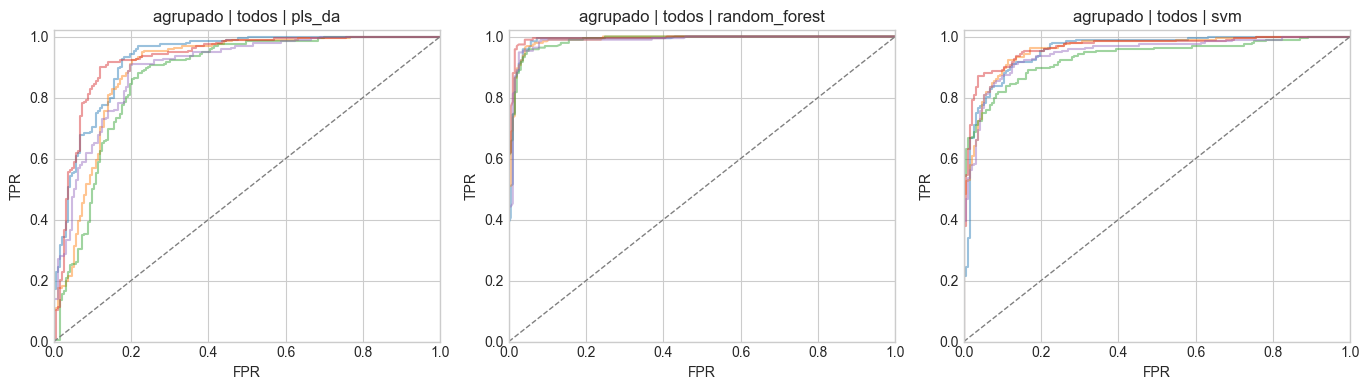

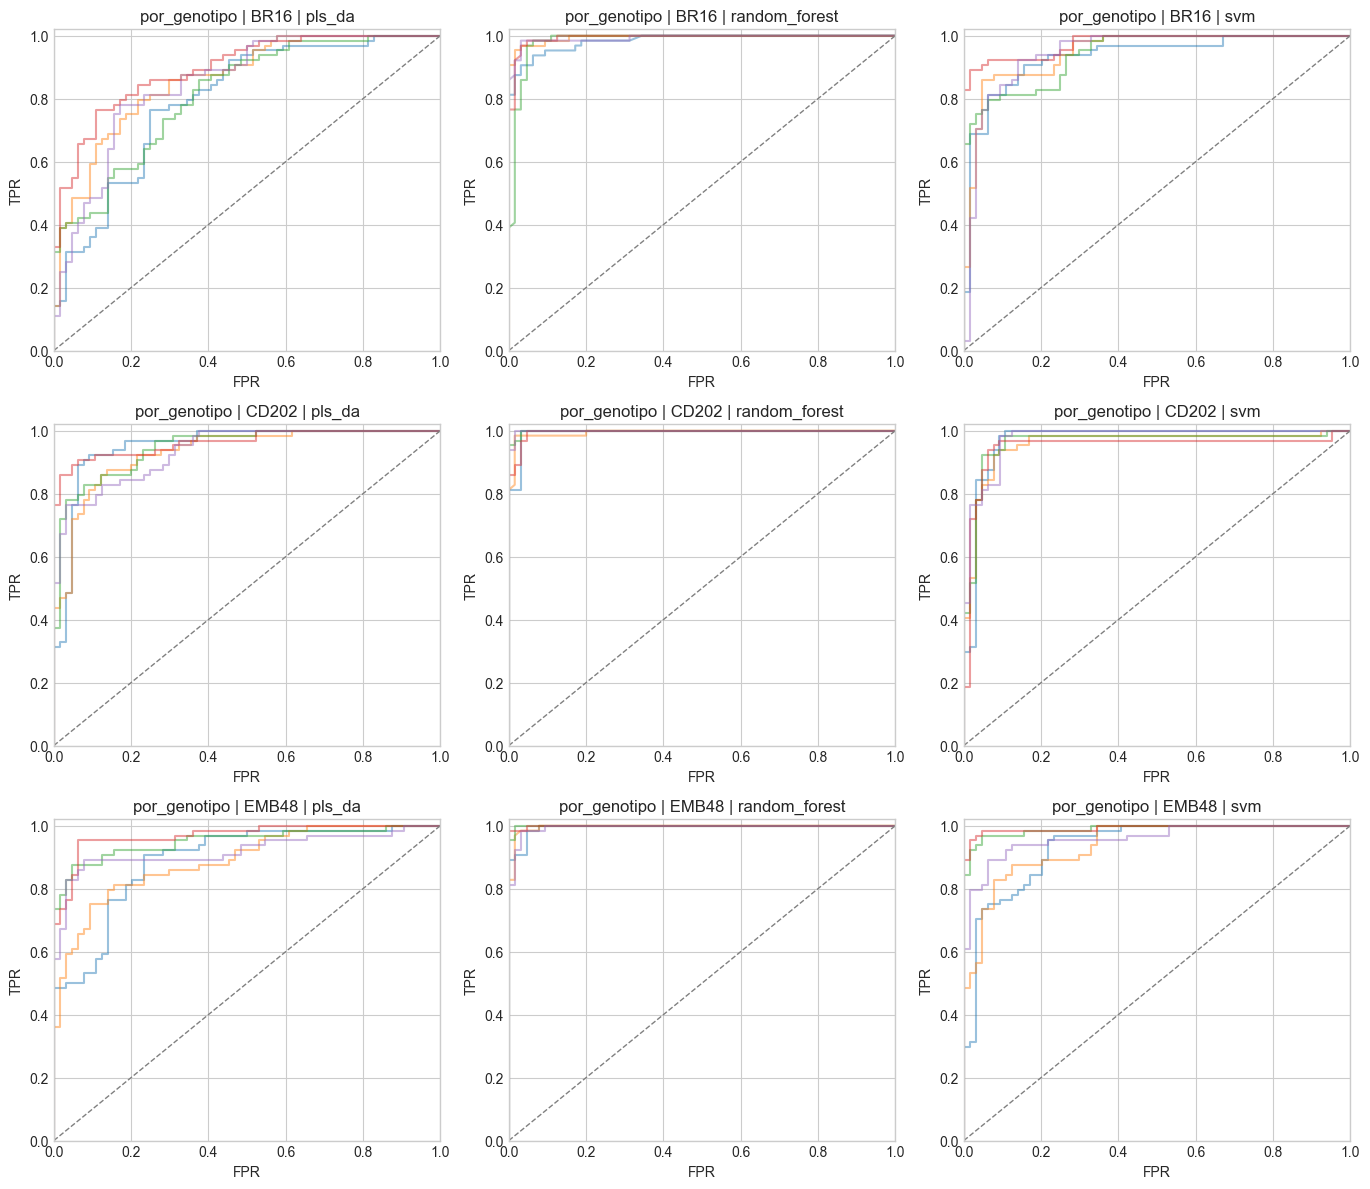

In [11]:
def plot_curvas_roc(df, modo=None, genotipo=None):
    if plt is None:
        print("Grafico pulado: instale matplotlib para visualizar.")
        return
    if df.empty:
        print("Sem dados para plotar.")
        return

    dados = df.copy()
    if modo is not None:
        dados = dados[dados["modo"] == modo]
    if genotipo is not None:
        dados = dados[dados["genotipo"] == genotipo]

    if dados.empty:
        print("Sem curvas para o filtro escolhido.")
        return

    cenarios = dados[["modelo", "modo", "genotipo"]].drop_duplicates().to_dict("records")
    n = len(cenarios)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.6, rows * 4.0))
    axes = np.array(axes).reshape(-1)

    for ax, cenario in zip(axes, cenarios):
        sub = dados[
            (dados["modelo"] == cenario["modelo"])
            & (dados["modo"] == cenario["modo"])
            & (dados["genotipo"] == cenario["genotipo"])
        ]
        for fold, fold_df in sub.groupby("fold"):
            ax.plot(fold_df["fpr"], fold_df["tpr"], alpha=0.45, label=f"fold {fold}")
        ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"{cenario['modo']} | {cenario['genotipo']} | {cenario['modelo']}")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)

    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_curvas_roc(curvas_roc, modo="agrupado")
plot_curvas_roc(curvas_roc, modo="por_genotipo")

## 7. Importancia das bandas e coeficientes

In [12]:
display(importancia_rf.head(20))
display(importancia_svm.head(20))
display(coeficientes_pls.head(20))

,modelo,modo,genotipo,fold,banda_nm,importancia,arquivo_origem
0,random_forest,agrupado,todos,1,401,0.352870,agrupado\random_forest\importancia_bandas.csv
1,random_forest,agrupado,todos,1,1939,0.211232,agrupado\random_forest\importancia_bandas.csv
2,random_forest,agrupado,todos,1,1356,0.184988,agrupado\random_forest\importancia_bandas.csv
3,random_forest,agrupado,todos,1,1843,0.137005,agrupado\random_forest\importancia_bandas.csv
4,random_forest,agrupado,todos,1,1385,0.113905,agrupado\random_forest\importancia_bandas.csv
5,random_forest,agrupado,todos,2,401,0.350741,agrupado\random_forest\importancia_bandas.csv
6,random_forest,agrupado,todos,2,1939,0.231467,agrupado\random_forest\importancia_bandas.csv
7,random_forest,agrupado,todos,2,1356,0.184244,agrupado\random_forest\importancia_bandas.csv
8,random_forest,agrupado,todos,2,1843,0.131884,agrupado\random_forest\importancia_bandas.csv
9,random_forest,agrupado,todos,2,1385,0.101664,agrupado\random_forest\importancia_bandas.csv


,modelo,modo,genotipo,fold,banda_nm,importancia_media,importancia_desvio,arquivo_origem
0,svm,agrupado,todos,1,401,0.331515,0.021850,agrupado\svm\importancia_permutacao.csv
1,svm,agrupado,todos,1,1843,0.111688,0.013858,agrupado\svm\importancia_permutacao.csv
2,svm,agrupado,todos,1,1939,0.057489,0.010619,agrupado\svm\importancia_permutacao.csv
3,svm,agrupado,todos,1,1356,0.025628,0.010427,agrupado\svm\importancia_permutacao.csv
4,svm,agrupado,todos,1,1385,0.021991,0.009596,agrupado\svm\importancia_permutacao.csv
5,svm,agrupado,todos,2,401,0.327965,0.021196,agrupado\svm\importancia_permutacao.csv
6,svm,agrupado,todos,2,1843,0.124502,0.012706,agrupado\svm\importancia_permutacao.csv
7,svm,agrupado,todos,2,1939,0.044502,0.012524,agrupado\svm\importancia_permutacao.csv
8,svm,agrupado,todos,2,1385,0.031688,0.011069,agrupado\svm\importancia_permutacao.csv
9,svm,agrupado,todos,2,1356,0.030043,0.009711,agrupado\svm\importancia_permutacao.csv


,modelo,modo,genotipo,fold,banda_nm,coeficiente,arquivo_origem
0,pls_da,agrupado,todos,1,1356,-7.032349,agrupado\pls_da\coeficientes_pls.csv
1,pls_da,agrupado,todos,1,1939,2.240717,agrupado\pls_da\coeficientes_pls.csv
2,pls_da,agrupado,todos,1,1385,-1.393718,agrupado\pls_da\coeficientes_pls.csv
3,pls_da,agrupado,todos,1,401,-1.179889,agrupado\pls_da\coeficientes_pls.csv
4,pls_da,agrupado,todos,1,1843,-1.143729,agrupado\pls_da\coeficientes_pls.csv
5,pls_da,agrupado,todos,2,1356,-7.291027,agrupado\pls_da\coeficientes_pls.csv
6,pls_da,agrupado,todos,2,1939,2.341337,agrupado\pls_da\coeficientes_pls.csv
7,pls_da,agrupado,todos,2,1385,-1.364921,agrupado\pls_da\coeficientes_pls.csv
8,pls_da,agrupado,todos,2,401,-1.158992,agrupado\pls_da\coeficientes_pls.csv
9,pls_da,agrupado,todos,2,1843,-0.997989,agrupado\pls_da\coeficientes_pls.csv


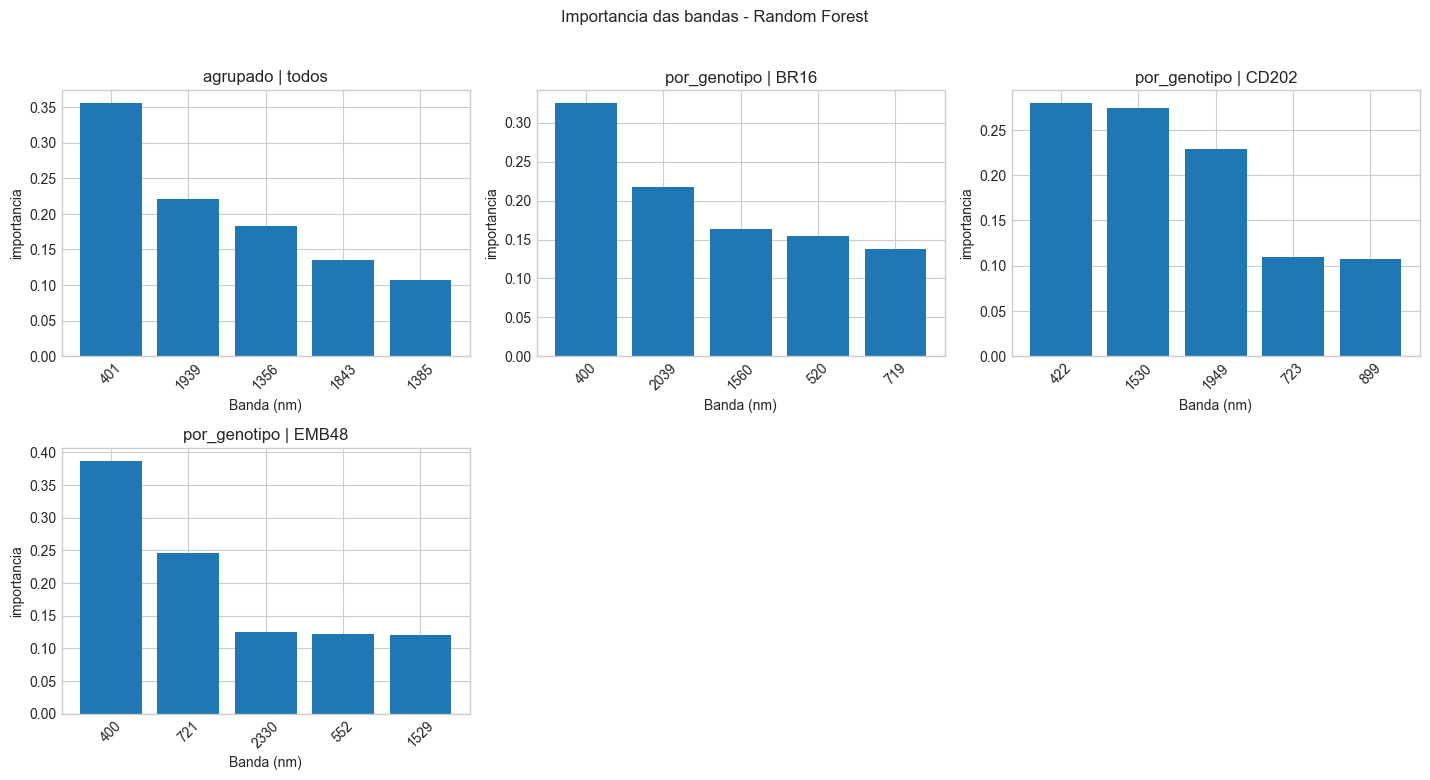

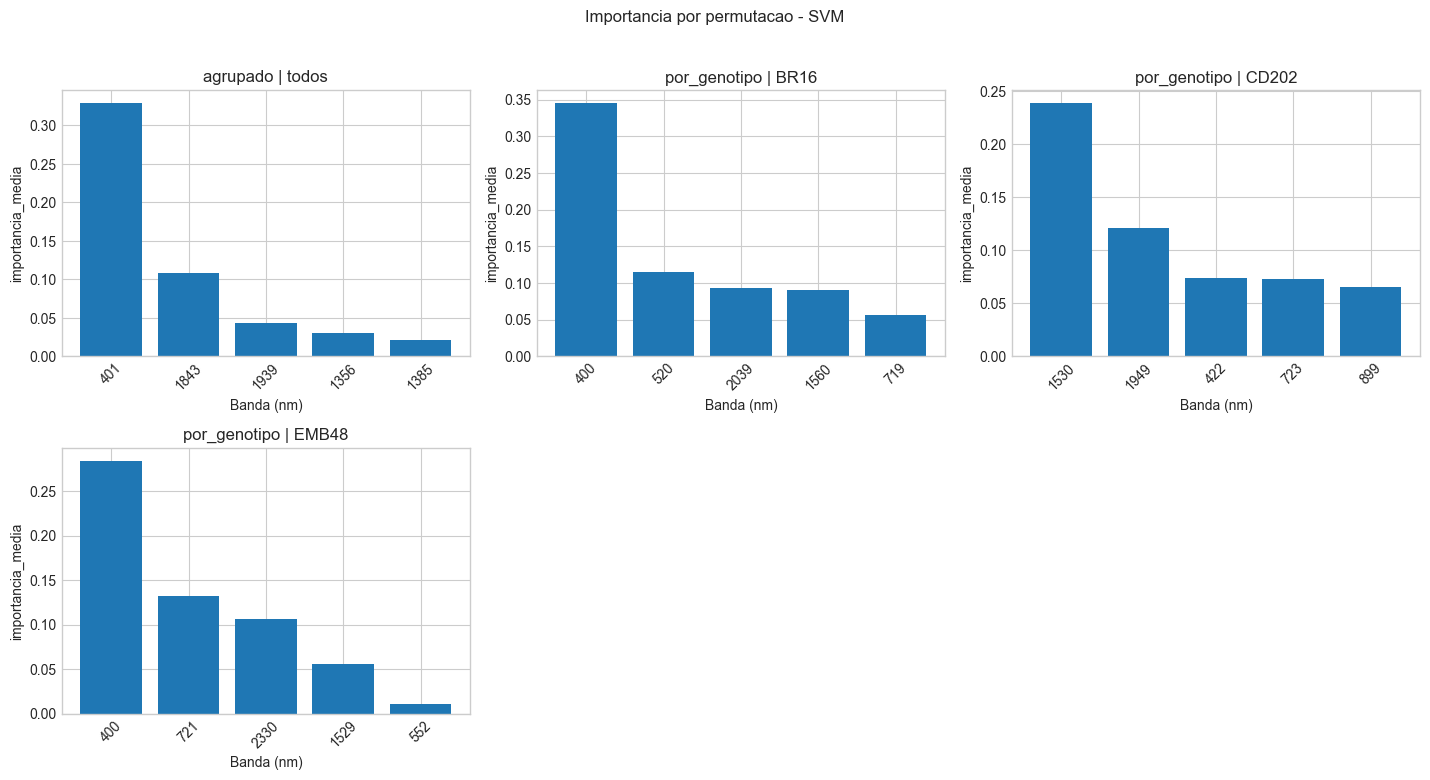

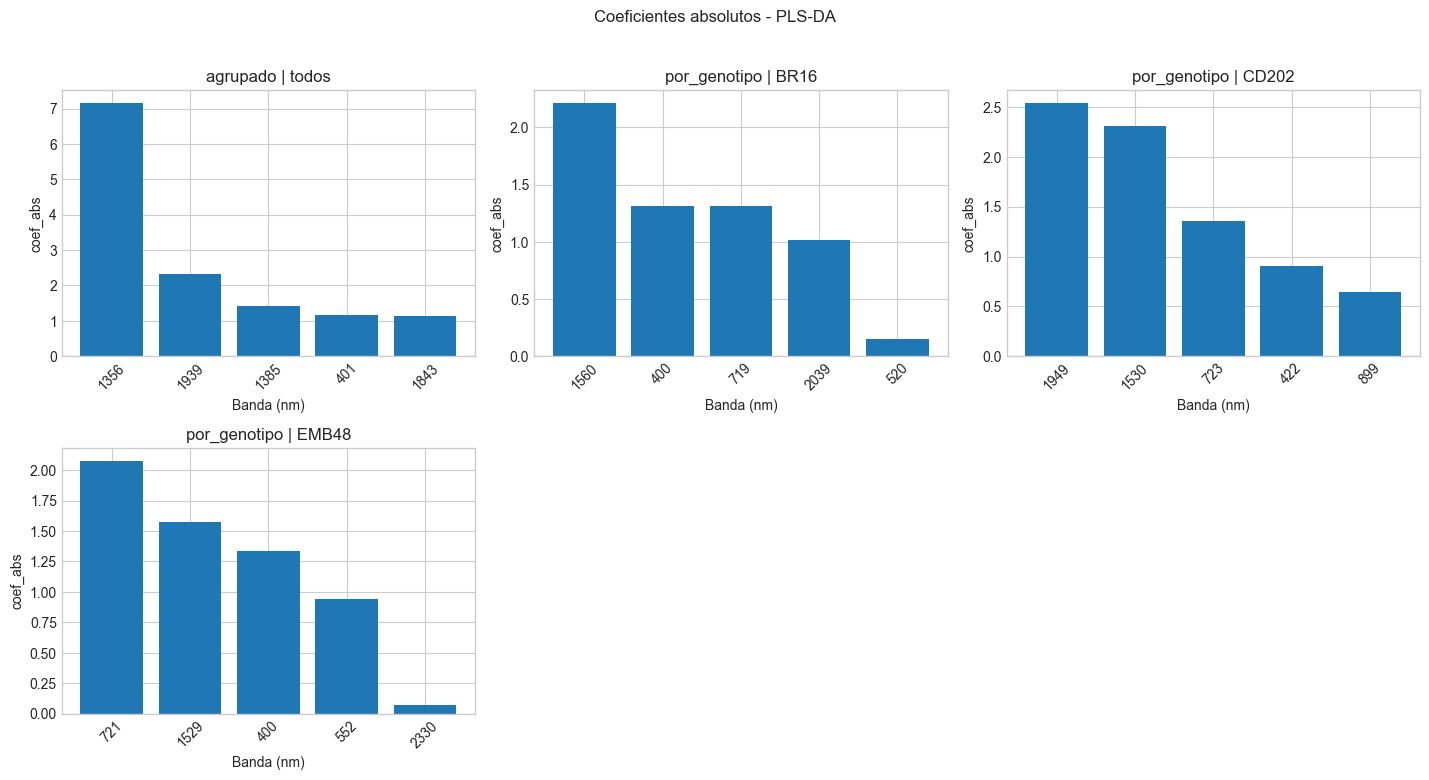

In [13]:
def plot_importancias(df, valor_col, titulo):
    if plt is None:
        print("Grafico pulado: instale matplotlib para visualizar.")
        return
    if df.empty:
        print(f"Sem dados para {titulo}.")
        return

    dados = df.copy()
    dados["cenario"] = dados["modo"] + " | " + dados["genotipo"].astype(str) + " | fold " + dados["fold"].astype(str)
    resumo = (
        dados.groupby(["modelo", "modo", "genotipo", "banda_nm"], as_index=False)[valor_col]
        .mean()
        .sort_values(["modo", "genotipo", valor_col], ascending=[True, True, False])
    )

    cenarios = resumo[["modelo", "modo", "genotipo"]].drop_duplicates().to_dict("records")
    n = len(cenarios)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.8, rows * 3.8))
    axes = np.array(axes).reshape(-1)

    for ax, cenario in zip(axes, cenarios):
        sub = resumo[
            (resumo["modelo"] == cenario["modelo"])
            & (resumo["modo"] == cenario["modo"])
            & (resumo["genotipo"] == cenario["genotipo"])
        ]
        ax.bar(sub["banda_nm"].astype(str), sub[valor_col])
        ax.set_title(f"{cenario['modo']} | {cenario['genotipo']}")
        ax.set_xlabel("Banda (nm)")
        ax.set_ylabel(valor_col)
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()
    plt.show()

plot_importancias(importancia_rf, "importancia", "Importancia das bandas - Random Forest")
plot_importancias(importancia_svm, "importancia_media", "Importancia por permutacao - SVM")
plot_importancias(coeficientes_pls.assign(coef_abs=coeficientes_pls.get("coeficiente", pd.Series(dtype=float)).abs()), "coef_abs", "Coeficientes absolutos - PLS-DA")

## 8. Leituras rapidas

In [14]:
if metricas_resumo.empty:
    print("Nao ha metricas carregadas.")
else:
    melhor_acc = metricas_resumo.loc[metricas_resumo["accuracy_media"].idxmax()]
    melhor_auc = metricas_resumo.loc[metricas_resumo["auc_roc_media"].idxmax()]

    print("Melhor accuracy media:")
    print(f"  {melhor_acc['modelo']} | {melhor_acc['modo']} | {melhor_acc['genotipo']} = {melhor_acc['accuracy_media']:.4f}")
    print("Melhor AUC-ROC media:")
    print(f"  {melhor_auc['modelo']} | {melhor_auc['modo']} | {melhor_auc['genotipo']} = {melhor_auc['auc_roc_media']:.4f}")

    print("\nModelos/cenarios avaliados:")
    display(metricas_resumo[["modelo", "modo", "genotipo"]].drop_duplicates().reset_index(drop=True))

Melhor accuracy media:
  random_forest | por_genotipo | CD202 = 0.9720
Melhor AUC-ROC media:
  random_forest | por_genotipo | EMB48 = 0.9969

Modelos/cenarios avaliados:


,modelo,modo,genotipo
0,pls_da,agrupado,todos
1,random_forest,agrupado,todos
2,svm,agrupado,todos
3,pls_da,por_genotipo,BR16
4,random_forest,por_genotipo,BR16
5,svm,por_genotipo,BR16
6,pls_da,por_genotipo,CD202
7,random_forest,por_genotipo,CD202
8,svm,por_genotipo,CD202
9,pls_da,por_genotipo,EMB48
